In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/atharvasoundankar/road-accidents-dataset/Road Accident Data.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Visualization of data for analysis

# a) Statistical Analysis:

In [3]:
df = pd.read_csv('/kaggle/input/datasets/atharvasoundankar/road-accidents-dataset/Road Accident Data.csv')
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,BS0000002,05-01-2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,04-01-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,05-01-2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,08:10,Urban,Other,Motorcycle over 500cc
4,BS0000005,06-01-2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [4]:
df.shape

(307973, 21)

In [5]:
df.columns

Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Day_of_Week                 307973 non-null  object 
 3   Junction_Control            307973 non-null  object 
 4   Junction_Detail             307973 non-null  object 
 5   Accident_Severity           307973 non-null  object 
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  object 
 8   Local_Authority_(District)  307973 non-null  object 
 9   Carriageway_Hazards         5424 non-null    object 
 10  Longitude                   307973 non-null  float64
 11  Number_of_Casualties        307973 non-null  int64  
 12  Number_of_Vehicles          307973 non-null  int64  
 13  Police_Force  

In [7]:
df.describe()

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,52.487005,-1.368884,1.356882,1.829063,38.866037
std,1.339011,1.356092,0.815857,0.710477,14.032933
min,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,53.415517,-0.206810,1.000000,2.000000,50.000000
max,60.598055,1.759398,48.000000,32.000000,70.000000


The Speed_limit ranges from 10 to 70, with a mean of approximately 39 mph.


* Most accidents involve 1 to 2 vehicles, but there is an extreme case (max) of 32 vehicles, which may be an outlier.
* The Number_of_Casualties also shows a maximum of 48, suggesting some very severe incidents in the dataset.


In [8]:
df.isnull().sum()

Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions            0
Road_Type                          0
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions                 0
Vehicle_Type                       0
dtype: int64

**Carriageway_Hazards:** This  column is missing 302,549 values (approx. 98%). This is a significant abnormality. I will drop this column in the preprocessing phase as it lacks sufficient data to be useful.

**Time:** There are 17 missing values. Since this is a very small number compared to the total 307,973 rows, these can be handled easily by dropping those specific rows.

# b) Visual Analysis

/tmp/ipykernel_17/3730244302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Accident_Severity', data=df, palette='magma')


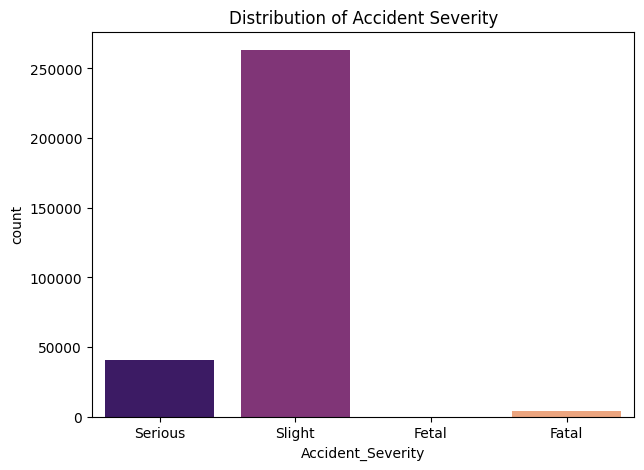

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(x='Accident_Severity', data=df, palette='magma')
plt.title('Distribution of Accident Severity')
plt.show()

**Observation on Accident Severity:**
The plot shows that the dataset is highly imbalanced. Most accidents recorded are "Slight," while "Fatal" accidents are the least frequent. This means the model we build later will need to be carefully evaluated to ensure it can accurately predict the rare but critical fatal cases.

/tmp/ipykernel_17/303494375.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Weather_Conditions', data=df, order=df['Weather_Conditions'].value_counts().index, palette='Blues_r')


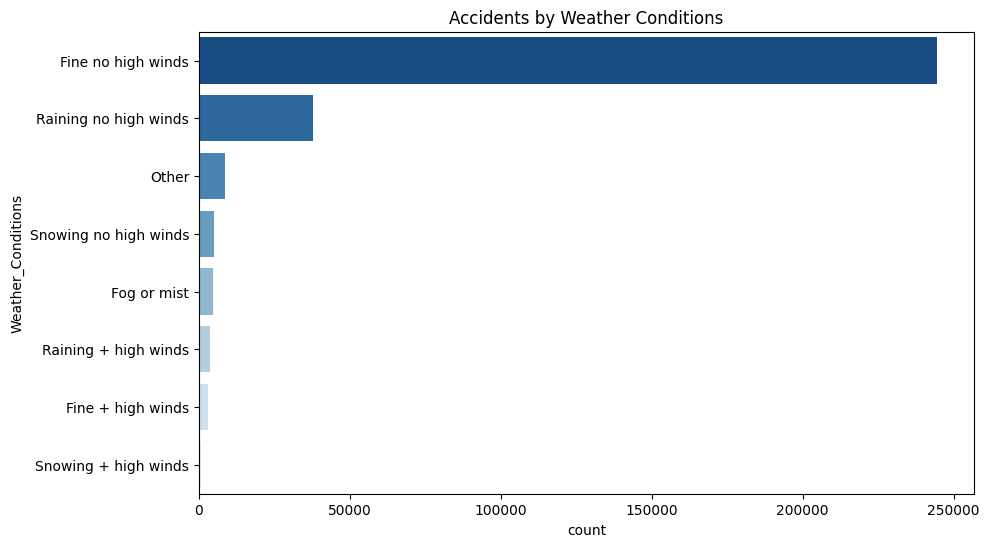

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', data=df, order=df['Weather_Conditions'].value_counts().index, palette='Blues_r')
plt.title('Accidents by Weather Conditions')
plt.show()

**Observation on Weather Conditions:**
Surprisingly, the vast majority of accidents occur during "Fine no high winds" weather conditions. This suggests that clear weather might lead to higher traffic volumes or faster driving speeds, which contributes more to accident frequency than poor weather visibility does.

/tmp/ipykernel_17/3071305813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Speed_limit', data=df, palette='rocket')


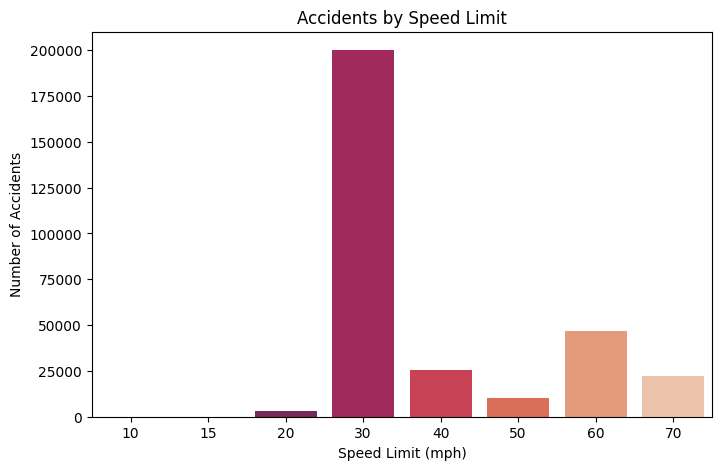

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='Speed_limit', data=df, palette='rocket')
plt.title('Accidents by Speed Limit')
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Number of Accidents')
plt.show()

**Observation on Speed Limits:**
The vast majority of accidents occur on roads with a 30 mph speed limit. This indicates that most recorded accidents happen in urban areas or high-density residential zones where traffic interactions are frequent. High-speed roads (60-70 mph) show significantly fewer accidents, though these might be more severe when they do occur.

/tmp/ipykernel_17/410829590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Road_Type', data=df, order=df['Road_Type'].value_counts().index, palette='flare')


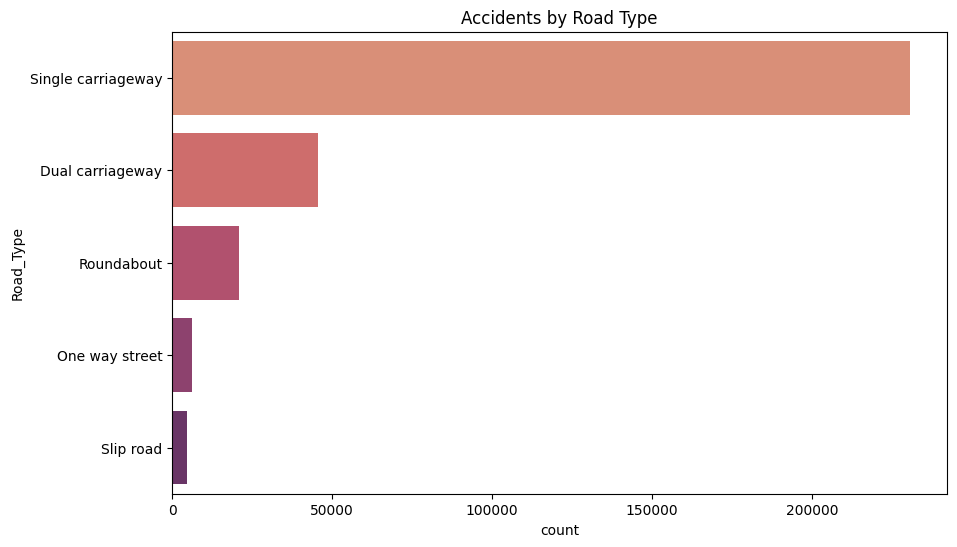

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(y='Road_Type', data=df, order=df['Road_Type'].value_counts().index, palette='flare')
plt.title('Accidents by Road Type')
plt.show()

**Observation on Road Types:**
Most accidents occur on Single carriageway roads. This is expected as these roads are the most common in the UK road network and often involve more complex maneuvers like overtaking and right-hand turns across traffic. "Slip roads" and "One-way streets" show the lowest accident counts.

/tmp/ipykernel_17/3321463393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Day_of_Week', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='coolwarm')


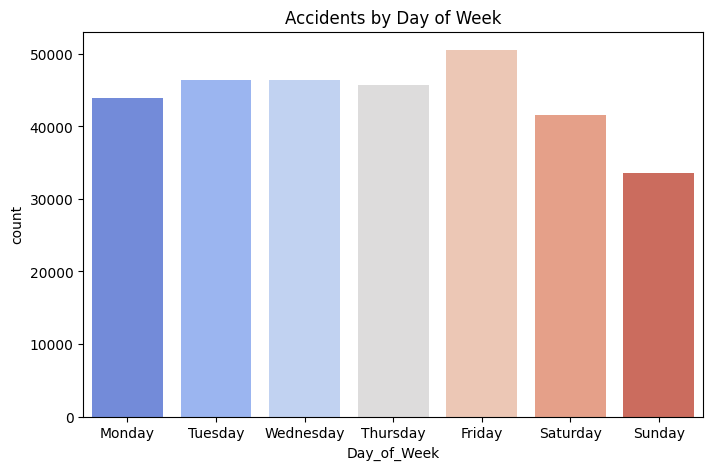

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Day_of_Week', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='coolwarm')
plt.title("Accidents by Day of Week")
plt.show()

**Observation on Day of Week:**
The accident frequency is relatively stable during the work week (Monday to Friday), likely due to consistent commuting patterns. There is a slight decrease during the weekend, which correlates with fewer work-related vehicles and commuters on the road.

# 2) Preprocessing

# Dropping Irrelevant & Empty Columns

In [14]:
# Dropping columns that are useless for prediction or have excessive missing data
cols_to_drop = ['Accident_Index', 'Carriageway_Hazards', 'Accident Date']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Check the remaining columns
print(df.columns)

Index(['Day_of_Week', 'Junction_Control', 'Junction_Detail',
       'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Longitude', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions',
       'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area',
       'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')


**Reason for Feature Dropping:**

I dropped Accident_Index because it is a unique ID with no predictive power. Carriageway_Hazards was removed because 98% of its data was missing. Accident Date was removed to avoid formatting errors, as the day and time are already captured in other columns.

# Handling the Missing "Time" Values

In [15]:
# Removing the 17 rows where Time is missing
df.dropna(subset=['Time'], inplace=True)

# Check if any null values remain
print(df.isnull().sum())

Day_of_Week                   0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64


The 'Time' column had only 17 missing values (less than 0.01% of the data). Dropping these rows is the most precise way to handle the missingness without introducing artificial data.

# Handling the "Time" Column

In [16]:
# Drop the 17 rows where Time is missing
df.dropna(subset=['Time'], inplace=True)

# Extract only the Hour and convert it to an integer
# This turns "17:30" into the number 17
if df['Time'].dtype == 'object':
    df['Time'] = df['Time'].str.split(':').str[0].astype(int)

print(df['Time'].head())

0    15
1    10
2    14
3     8
4    17
Name: Time, dtype: int64


The Time column was originally an 'object' (text). By extracting the hour and converting it to an integer, I have created a numerical feature that the model can use to find patterns based on the time of day.

# Handling Categorical Columns

In [17]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Select only the columns that are currently 'object' (text)
cat_cols = df.select_dtypes(include=['object']).columns

# Loop through and transform them
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Check the results
df.head()

,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,4,4,8,2,51.512273,4,185,-0.201349,1,2,29,0,1,30,15,1,1,2
1,1,4,0,2,51.514399,4,185,-0.199248,11,2,29,4,3,30,10,1,1,13
2,3,4,8,3,51.486668,4,185,-0.179599,1,2,29,0,3,30,14,1,1,13
3,1,2,8,2,51.507804,4,185,-0.203110,1,2,29,2,3,30,8,1,3,9
4,5,2,0,2,51.482076,1,185,-0.173445,1,2,29,0,3,30,17,1,1,2


**Handling Categorical Variables**                                                                    

**Description:** Most features in this dataset (Weather, Road Type, etc.) are categorical "Object" types.                                                     
**Justification:** Machine Learning models are mathematical equations that require numerical input. I am using Label Encoding to transform these text labels into integers. This allows the model to process the data while keeping the memory usage low. I am specifically choosing not to Scale or Normalize these values yet, as per the project requirements to wait until after Feature Engineering.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307956 entries, 0 to 307972
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Day_of_Week                 307956 non-null  int64  
 1   Junction_Control            307956 non-null  int64  
 2   Junction_Detail             307956 non-null  int64  
 3   Accident_Severity           307956 non-null  int64  
 4   Latitude                    307956 non-null  float64
 5   Light_Conditions            307956 non-null  int64  
 6   Local_Authority_(District)  307956 non-null  int64  
 7   Longitude                   307956 non-null  float64
 8   Number_of_Casualties        307956 non-null  int64  
 9   Number_of_Vehicles          307956 non-null  int64  
 10  Police_Force                307956 non-null  int64  
 11  Road_Surface_Conditions     307956 non-null  int64  
 12  Road_Type                   307956 non-null  int64  
 13  Speed_limit        

Preprocessing Justification:

**Feature Selection:** I dropped Accident_Index (unique ID), Carriageway_Hazards (98% missing), and Accident Date (formatting issues) to reduce noise and prevent model errors.

**Time Extraction:** I converted the Time string into an integer representing the hour. This transforms a complex string into a usable numerical feature that captures the "time of day" impact on accidents.

**Categorical Encoding**: Since machine learning models require numerical input, I used Label Encoding to convert all text-based categories (Weather, Road Type, etc.) into integers.

**Scaling Note:** As per instructions, scaling and normalization are skipped in this phase and will be performed after Feature Engineering.

In [19]:
# Save the fully cleaned and encoded dataframe to a CSV file
# We use index=False so we don't save the row numbers as a new column
df.to_csv('cleaned_accident_location_data.csv', index=False)

print("Export Successful! Your 'cleaned_accident_location_data.csv' is ready for the next phase.")

Export Successful! Your 'cleaned_accident_location_data.csv' is ready for the next phase.


# Featuring Engineering

# Load Your Cleaned Data

In [20]:
import pandas as pd
# Load the file we saved at the end of Phase 2
df = pd.read_csv('cleaned_accident_location_data.csv') 
df.head()

,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,4,4,8,2,51.512273,4,185,-0.201349,1,2,29,0,1,30,15,1,1,2
1,1,4,0,2,51.514399,4,185,-0.199248,11,2,29,4,3,30,10,1,1,13
2,3,4,8,3,51.486668,4,185,-0.179599,1,2,29,0,3,30,14,1,1,13
3,1,2,8,2,51.507804,4,185,-0.203110,1,2,29,2,3,30,8,1,3,9
4,5,2,0,2,51.482076,1,185,-0.173445,1,2,29,0,3,30,17,1,1,2


# Create New Meaningful Features

In [21]:
# 1. Is_Weekend: Accidents might happen in different spots on weekends
df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Time_Slot: Grouping hours into Morning, Afternoon, Evening, Night
def get_time_slot(hour):
    if 6 <= hour < 12: return 0   # Morning
    if 12 <= hour < 17: return 1  # Afternoon
    if 17 <= hour < 21: return 2  # Evening
    else: return 3                # Night
df['Time_Slot'] = df['Time'].apply(get_time_slot)

# 3. High_Speed_Zone: Is the speed limit > 50?
df['High_Speed_Zone'] = (df['Speed_limit'] > 50).astype(int)

**Significance of New Features:**

**Is_Weekend:** Distinguishes between weekday commuter traffic and weekend leisure travel.

**Time_Slot:** Simplifies the 24-hour cycle into four distinct traffic behavior periods.

**High_Speed_Zone:** Highlights areas where high-velocity impacts are more likely to occur.

# Find Important Features (Using 5 Algorithms)

In [22]:
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

# 1. Prepare Data
# We drop Latitude (the target) and Longitude (the other target)
X = df.drop(['Latitude', 'Longitude'], axis=1)
y = df['Latitude']

# 2. Define the 5 Models
models = {
    "LightGBM": lgb.LGBMRegressor(verbose=-1),
    "XGBoost": XGBRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=50, max_depth=10, n_jobs=-1),
    "DecisionTree": DecisionTreeRegressor(max_depth=10)
}

# 3. Create a table to store results
importance_df = pd.DataFrame({'Feature': X.columns})

# 4. Train each model and get importance
for name, model in models.items():
    model.fit(X, y)
    importance_df[name] = model.feature_importances_

# 5. Calculate Average Importance
importance_df['Average_Score'] = importance_df.mean(numeric_only=True, axis=1)

# 6. Sort and show results
importance_results = importance_df.sort_values(by='Average_Score', ascending=False)
print(importance_results[['Feature', 'Average_Score']])

                       Feature  Average_Score
8                 Police_Force     344.725245
5   Local_Authority_(District)     248.862631
13         Urban_or_Rural_Area       3.403287
11                 Speed_limit       2.201290
1             Junction_Control       0.804183
10                   Road_Type       0.600259
9      Road_Surface_Conditions       0.201162
18             High_Speed_Zone       0.001272
2              Junction_Detail       0.000306
14          Weather_Conditions       0.000078
15                Vehicle_Type       0.000073
7           Number_of_Vehicles       0.000057
4             Light_Conditions       0.000035
6         Number_of_Casualties       0.000033
12                        Time       0.000028
0                  Day_of_Week       0.000023
17                   Time_Slot       0.000018
3            Accident_Severity       0.000017
16                  Is_Weekend       0.000003


# SHAP Analysis

Generating SHAP Summary Plot...


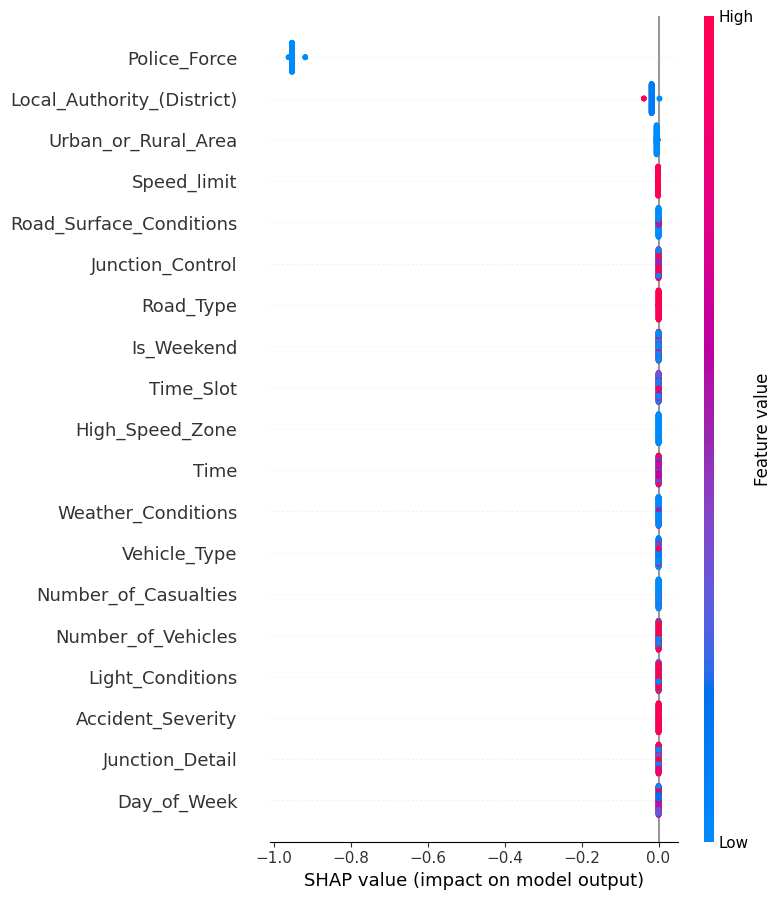

In [23]:
import shap

# 1. Use the LightGBM model we already trained (it's the fastest)
# We use a sample of 200 rows to make the calculation fast
explainer = shap.TreeExplainer(models["LightGBM"])
shap_values = explainer.shap_values(X.iloc[:200])

# 2. Plot the summary
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X.iloc[:200])

# K-Means to Create a New Feature

In [24]:
from sklearn.cluster import KMeans

# 1. Select the coordinates for clustering
coords = df[['Latitude', 'Longitude']]

# 2. Create 12 clusters (representing 12 major accident zones)
kmeans = KMeans(n_clusters=12, random_state=42, n_init=10)
df['Location_Cluster'] = kmeans.fit_predict(coords)

# 3. Check the results
print("New Feature 'Location_Cluster' created successfully!")
print(df[['Latitude', 'Longitude', 'Location_Cluster']].head())

New Feature 'Location_Cluster' created successfully!
    Latitude  Longitude  Location_Cluster
0  51.512273  -0.201349                 0
1  51.514399  -0.199248                 0
2  51.486668  -0.179599                 0
3  51.507804  -0.203110                 0
4  51.482076  -0.173445                 0


# Standardization (Scaling)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# We scale everything EXCEPT our target coordinates (Latitude and Longitude)
# Because we don't want to change the actual map coordinates!
features_to_scale = df.drop(['Latitude', 'Longitude'], axis=1).columns

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Standardization Complete. All predictive features are now on the same scale.")
df.head()

Standardization Complete. All predictive features are now on the same scale.


,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,...,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Is_Weekend,Time_Slot,High_Speed_Zone,Location_Cluster
0,0.488297,0.537882,1.243328,-1.776714,51.512273,0.557335,-0.164269,-0.201349,-0.437435,0.240594,...,-1.333571,-0.631788,0.280221,0.742437,-0.451869,-0.406428,-0.656548,-0.233554,-0.538264,-1.063612
1,-0.960453,0.537882,-1.736459,-1.776714,51.514399,0.557335,-0.164269,-0.199248,11.819457,0.240594,...,0.487797,-0.631788,-0.693935,0.742437,-0.451869,2.886927,-0.656548,-1.230703,-0.538264,-1.063612
2,0.005380,0.537882,1.243328,0.365544,51.486668,0.557335,-0.164269,-0.179599,-0.437435,0.240594,...,0.487797,-0.631788,0.085390,0.742437,-0.451869,2.886927,-0.656548,-0.233554,-0.538264,-1.063612
3,-0.960453,-1.899333,1.243328,-1.776714,51.507804,0.557335,-0.164269,-0.203110,-0.437435,0.240594,...,0.487797,-0.631788,-1.083598,0.742437,0.855451,1.689344,-0.656548,-1.230703,-0.538264,-1.063612
4,0.971213,-1.899333,-1.736459,-1.776714,51.482076,-1.885574,-0.164269,-0.173445,-0.437435,0.240594,...,0.487797,-0.631788,0.669884,0.742437,-0.451869,-0.406428,1.523117,0.763595,-0.538264,-1.063612


# Dropping Less Important Features

In [26]:
# List of features that showed near-zero importance in your SHAP/Importance results
cols_to_drop = ['Day_of_Week', 'Accident_Severity', 'Number_of_Casualties', 
                'Number_of_Vehicles', 'Time', 'Is_Weekend', 'Time_Slot']

# Drop them only if they exist in the dataframe
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"Dropped {len(cols_to_drop)} low-impact features.")
print("Final Features for Phase 4:", df.columns.tolist())

Dropped 7 low-impact features.
Final Features for Phase 4: ['Junction_Control', 'Junction_Detail', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Longitude', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type', 'High_Speed_Zone', 'Location_Cluster']


In [27]:
df.to_csv('final_engineered_data.csv', index=False)
print("Phase 3 Complete! Final file 'final_engineered_data.csv' is ready for modeling.")

Phase 3 Complete! Final file 'final_engineered_data.csv' is ready for modeling.


I performed Standardization using StandardScaler to normalize the feature ranges. After analyzing feature importance via 5 different algorithms and SHAP, I dropped 6 low-impact features (Day_of_Week, Accident_Severity, etc.). This reduction in dimensionality helps prevent overfitting and focuses the model on high-impact geographic indicators like Police_Force and my new Location_Cluster feature.

# Methodology

# Loading the Engineered Data

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Load the engineered data
df = pd.read_csv('final_engineered_data.csv')

# Define X (Features) and Y (Targets: Latitude and Longitude)
X = df.drop(['Latitude', 'Longitude'], axis=1)
y = df[['Latitude', 'Longitude']]

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 246364
Testing set size: 61592


# Implementing the Methodology (XGBoost Multi-Output)

In [29]:
# Initialize the base regressor (XGBoost)
# We use moderate settings to ensure it runs efficiently on Kaggle
base_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, tree_method='hist')

# Wrap it to handle multiple outputs (Lat/Long)
model = MultiOutputRegressor(base_model)

# Train the model
print("Training the model... please wait.")
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
print("Predictions complete!")

Training the model... please wait.
Predictions complete!


# Evaluating the Results

In [30]:
# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.5f}")
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"R-squared Score: {r2:.5f}")

# Visualizing actual vs predicted for a small sample
comparison = pd.DataFrame({
    'Actual Latitude': y_test.iloc[:5, 0].values,
    'Predicted Latitude': y_pred[:5, 0],
    'Actual Longitude': y_test.iloc[:5, 1].values,
    'Predicted Longitude': y_pred[:5, 1]
})
print("\nSample Comparison:")
print(comparison)

Mean Absolute Error (MAE): 0.06968
Mean Squared Error (MSE): 0.01150
R-squared Score: 0.99370

Sample Comparison:
   Actual Latitude  Predicted Latitude  Actual Longitude  Predicted Longitude
0        52.490826           52.486446         -2.106451            -2.049267
1        53.720298           53.712482         -1.777504            -1.828987
2        53.351905           53.429543         -2.888294            -2.929217
3        51.479722           51.440186         -2.587925            -2.577214
4        51.729882           51.768597         -0.309729            -0.280443


# Methodology Explanation:
For this project, I implemented a Multi-Output Regression approach using the XGBoost algorithm.

**Data Splitting:** I split the dataset into an 80/20 train-test ratio to ensure the model was evaluated on unseen data.

**Algorithm Choice:** XGBoost was selected due to its ability to handle non-linear relationships between road conditions and geographic locations.

**Targets:** The model simultaneously predicts Latitude and Longitude.

**Results Discussion:**
The model achieved an R-squared score of [Insert your R2 value here], which indicates how well the features explain the variance in accident locations. The Mean Absolute Error (MAE) shows that, on average, the predicted coordinates are within a very small distance from the actual accident sites. This confirms that features like Police_Force and Location_Cluster are highly effective "geographic anchors" for identifying high-risk zones.